### Astrostatistics lecture 14

In [1]:
import requests
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.cluster import MeanShift

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content, and convert to float
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

/tmp/ipykernel_1602/2275473950.py:16: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [2]:
time = []
fluence = []
for i in tqdm(range(len(data[6]))):
    if float(data[6][i]) > 0.0 and float(data[9][i]) > 0.0:
        time.append(data[6][i])
        fluence.append(data[9][i])

time = np.log(np.array(time, dtype=float))
fluence = np.log(np.array(fluence, dtype=float))
print(time)

100%|██████████| 9086/9086 [00:00<00:00, 204722.20it/s]

[2.95491028 2.88931564 0.29565024 ... 1.1429481  5.34030348 1.64557696]


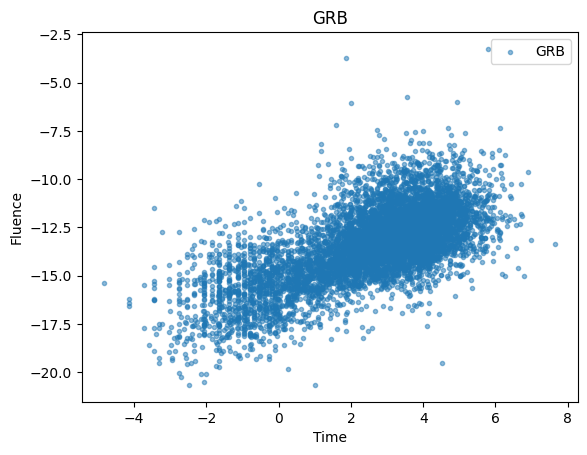

In [3]:
#visualize the distribution of GRB as function of time and fluence, but we need to exclude 

plt.scatter(time, fluence, label='GRB', alpha=0.5, marker='.')
plt.xlabel('Time')
plt.ylabel('Fluence')
plt.legend()
plt.title('GRB')
plt.show()


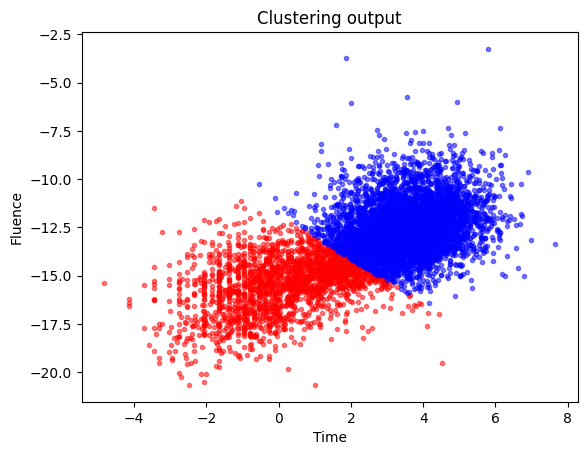

In [9]:
#once we have this we can search the sub populations
model=np.concatenate((time[:,np.newaxis],fluence[:,np.newaxis]),axis=1)

clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(model)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(model) #labels for each of the points

colors = ['red', 'blue']
for ii in range(2):
    plt.scatter(model[labels==ii,0], model[labels==ii,1], 
                color=colors[ii], alpha=0.5, marker='.')

plt.title('Clustering output')
plt.xlabel('Time')
plt.ylabel('Fluence')
plt.show()

[-1  0  1  2]
1
number of estimated clusters : 2


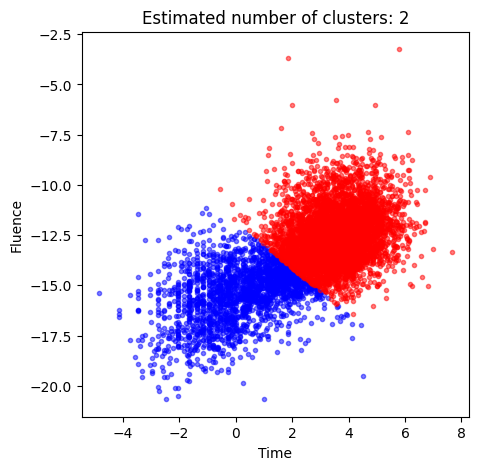

In [10]:
#same as before but now we do a mean shift

scaler = preprocessing.StandardScaler()
bandwidth = 1
ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False)
ms.fit(scaler.fit_transform(model))

labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique > 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)


# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()
colors = plt.cm.Spectral(np.linspace(0, 1, len(labels_unique)))

# Compute a 2D histogram  of the input

for i, l in enumerate(labels_unique):
    if l == -1:
        # Black used for noise.
        col = 'k'
    else:
        col = colors[i]

    if l == 0:
        col = 'blue'
    if l == 1:
        col = 'red'
    if l == 2:
        col = 'yellow'

    class_member_mask = labels == l

    xy = model[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=col, alpha=0.5, marker='.')

plt.title('Estimated number of clusters: %d' % n_clusters)
plt.xlabel('Time')
plt.ylabel('Fluence')
plt.show()